<a href="https://colab.research.google.com/github/yemioz/Numerical-Methods-Projects/blob/main/newton-raphson-secant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Participants: Madison Hays, Oluwayemisi Oyesanya, Dustin Tidmore

Professor: Dr. Jacob

Class: Numerical Methods

Group Project 3

Module: Nonlinear Equation Solving

Below are imported packages that will support the functions and expressions needed for the coding throughout this project.

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###Background Information

Included next are declared definitions, the continuous function from Project Part 1, and the Lagrange interpolation from Project Part 2.

In [ ]:
def true_error(true_value, approx_value):
   return true_value - approx_value


def relative_error(true_value, approx_value):
  return true_error(true_value, approx_value) / true_value


def approx_error(present_approx, previous_approx):
  return present_approx - previous_approx


def approx_relative_error(present_approx, previous_approx):
  return approx_error(previous_approx, present_approx) / present_approx


def relative_error_percent(present_approx, previous_approx):
  return abs(approx_error(previous_approx, present_approx) / present_approx)*100

In [ ]:
def Taylor_Coefficient(degree, input):
  return 4*(-1)**(degree)*(math.exp((-1)*input))/(math.factorial(degree))


def Taylor_Term(degree, input):
  return Taylor_Coefficient(degree, input)*((input - 3)**(degree))


def Taylor_Polynomial(degree, input):
  sum = 0

  for i in range(0, degree + 1):
    sum = sum + Taylor_Term(i, input)
  return sum


center = 3
function = lambda x: 4*math.exp(-x)-14*x
deriv_function = lambda x: -4*math.exp(-x)-14

In [ ]:
def lagrange_coefficient(input, output, index, variable):
  lang_coefficient = 1
  for i in range(len(input)):
    if i == index:
      continue
    else:
      lang_coefficient = lang_coefficient*(variable - input[i])/(input[index]-input[i])
  return lang_coefficient

def lagrange_interpolator(input, output, variable):
  lang_interpolator = 0
  for i in range(len(input)):
    lang_interpolator = lang_interpolator + lagrange_coefficient(input, output, i, variable)*output[i]
  return lang_interpolator

We have transformed our function for this project because our original function of $$4e^{-x}$$
has no roots. Therefore, our new function is $$4e^{-x}-14x.$$

###Newton-Raphson Method

The Newton-Raphson formula is given below: $$x_{i+1}=x_i-\frac{f(x_i)}{f'(x_i)}$$
We start with an initial guess of $x_i$ and use it to find the next guess $x_{i+1}$. This is repeated until we find a root within a desirable tolerance.

Below is an algorithm for finding roots of a function when both the function and derivative are known using the Newton-Raphson method.

In [ ]:
# creating the Newton-Raphson Method algorithm
def newton_step1(function, deriv_function, guess):
  return guess - function(guess)/deriv_function(guess)

def newton(function, deriv_function, guess, tolerance, max_iterations):
  x = guess
  for count in range(max_iterations):
    if deriv_function(x) == 0:
      print('Derivative is 0. No solution.')
      return None
    if abs(function(x)) < tolerance:
      return [x, count]
    x = newton_step1(function, deriv_function, x)
  return None

In [ ]:
newton(function,deriv_function,center,.0001,20)

[0.22756259497786627, 3]

This shows that our root is $0.2275625$ and it took 3 iterations.

In [ ]:
seed_values = [-18,-17.7,-16,-3,0.1,0.2,math.exp(1),center,5.6,64,200]
roots = []
iterations = []

for seed in seed_values:
  if newton(function,deriv_function,seed,.0001,20) != None:
    roots.append(newton(function,deriv_function,seed,.0001,20)[0])
    iterations.append(newton(function,deriv_function,seed,.0001,20)[1])
  else:
    roots.append('None Found')
    iterations.append('>20')


In [ ]:
# creating table with seed values
root_approx = {'Seed': [seeds for seeds in seed_values],
        'Roots': [root for root in roots],
        'Iterations': [iter for iter in iterations]}

root_table = pd.DataFrame(root_approx)
print(root_table)

          Seed       Roots Iterations
0   -18.000000  None Found        >20
1   -17.700000    0.227562         19
2   -16.000000    0.227563         18
3    -3.000000    0.227563          5
4     0.100000    0.227563          2
5     0.200000    0.227563          2
6     2.718282    0.227563          3
7     3.000000    0.227563          3
8     5.600000    0.227561          3
9    64.000000    0.227561          3
10  200.000000    0.227561          3


Our function does not converge for values $\le -18.$ It does converge everywhere else though, with surprisingly low iterations.

###Secant Method

The below equation is used for the secant method. $$x_{i+1}=x_i-\frac{f(x_i)(x_i-x_{i-1})}{f(x_i)-f(x_{i-1})}$$
This method requires two initial guesses and typically converges slower than the Newton-Raphson method.

Below is an algorithm for finding roots using the secant method.

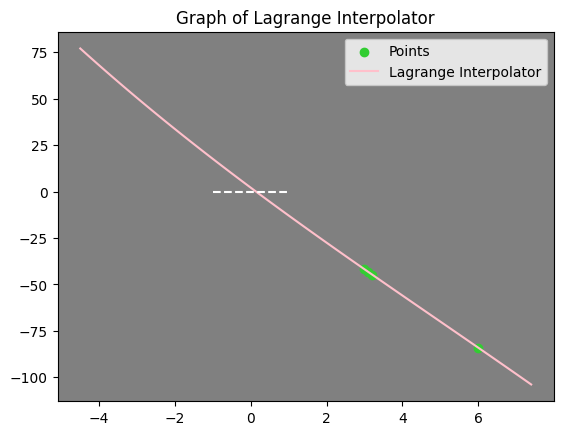

In [ ]:
# creating secant algorithm with lagrange interpoloation and graphing
iterations1 = []
error_list = []


def secant(function, guess_one, guess_two):
  root = guess_two - (function(guess_two)*(guess_two - guess_one))/(function(guess_two) - function(guess_one))
  return root

def secant_method(function, first_value, second_value, iterations):
  x = [first_value, second_value]
  for i in range(iterations):
    x.append(secant(function,x[-2],x[-1]))
    error = relative_error_percent(x[-1], x[-2])
    error_list.append(error)
  return x


input = [center, center+.1, center+.2, 2*center]
output = [function(value) for value in input]

x = np.arange(-4.5, 7.5, .1)

ax = plt.axes()
ax.set_facecolor('grey')

plt.scatter(input ,output, c='#32cd32')
plt.plot(x, lagrange_interpolator(input, output, x), c='pink')
plt.title('Graph of Lagrange Interpolator')
ax.hlines(y=0, xmin=-1, xmax=1, linestyle='--', color='w')
plt.legend(['Points', 'Lagrange Interpolator'])

plt.show()

We adjusted the window so that all necessary components are visible and included a dashed line at $y=0$ to make it clear where our root is located.

In [ ]:
lagrange_value = lambda x: lagrange_interpolator(input, output, x)
sec = secant_method(lagrange_value, -1, 1, 4)
sec

[-1,
 1,
 0.15399432975850558,
 0.1381772335292902,
 0.13837823914919684,
 0.13837818990633777]

Each approximation gets us closer to our root and the difference between each approximation is decreasing. We note that 23 iterations will break our function.

In [ ]:
#creating table for secant algorithm with 4 iterations and showing errors
secant_approx1 = {'First Value': [i for i in sec[:4]]}
secant_approx2 = {'Second Value': [i for i in sec[1:5]]}
secant_approx3 = {'Output': [i for i in sec[2:]]}
error_approx = {'Error': [i for i in error_list[:4]]}

secant_table1 = pd.DataFrame(secant_approx1)
secant_table2 = pd.DataFrame(secant_approx2)
secant_table3 = pd.DataFrame(secant_approx3)
error_table = pd.DataFrame(error_approx)

result = pd.concat([secant_table1, secant_table2, secant_table3, error_table],axis=1)
print(result)

   First Value  Second Value    Output       Error
0    -1.000000      1.000000  0.153994  549.374559
1     1.000000      0.153994  0.138177   11.446963
2     0.153994      0.138177  0.138378    0.145258
3     0.138177      0.138378  0.138378    0.000036


The table above uses the secant method and our Lagrange Interpolation to find roots. The table outputs roots until the error tolerance of $0.01\%$ is satisfied.

###Comments and Findings

In regards to the appropriateness of finding the roots of the known function $f(x)$, we actually had to change our function to one that was more appropriate to use Newton-Raphson on. Obviously, Newton-Raphson is inappropriate to use on a function that doesn't have roots.

We changed up our initial seeds a few times to find what values our function did not converge at. It was surprising, however, to see that even large seeds took only a relatively low number of iterations.

The Newton-Raphson has at least one easy to find issue. If you start at an $x$ value where the function $f(x)$ is at a maximum or minimum point on the graph, the tangent line will be fully horizontal at the point of the function. This means the tangent line will never touch the $x$ axis again, and we can't take another approximation.

In this case, we would certainly need to use another method to find our approximation.